## Lab 2
### Part 2: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recomment to use Google Colab or other machine with GPU acceleration.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [2]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print('Directory', path, 'is created!')
    else:
        print('Directory', path, 'already exists!')

root_path = 'fmnist'
mkdir(root_path)

Directory fmnist already exists!


In [3]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(root_path,
                                                        train=True,
                                                        transform=train_transform,
                                                        target_transform=None,
                                                        download=download)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(root_path,
                                                       train=False,
                                                       transform=test_transform,
                                                       target_transform=None,
                                                       download=download)

In [4]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train,
                                           batch_size=128,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=256,
                                          shuffle=False,
                                          num_workers=2)

In [5]:
len(fmnist_dataset_test)

10000

In [6]:
for img, label in train_loader:
    print(img.shape)
#     print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])
128


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [7]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [8]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                  [-1, 256]         131,328
              ReLU-5                  [-1, 256]               0
            Linear-6                   [-1, 10]           2,570
Total params: 535,818
Trainable params: 535,818
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 2.04
Estimated Total Size (MB): 2.06
----------------------------------------------------------------


Your experiments come here:

Citation: train function adapted from https://github.com/r-isachenko/dgm_utils.git

In [9]:
COMMIT_HASH = "79dfd7865ba692235f0a4d5aed20ee2820a19007"
!if [ -d dgm_utils ]; then rm -Rf dgm_utils; fi
!git clone https://github.com/r-isachenko/dgm_utils.git
%cd dgm_utils
!git checkout {COMMIT_HASH}
!pip install ./
%cd ./..
!rm -Rf dgm_utils

Cloning into 'dgm_utils'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 188 (delta 122), reused 85 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (188/188), 41.78 KiB | 713.00 KiB/s, done.
Resolving deltas: 100% (122/122), done.
/content/dgm_utils
Note: switching to '79dfd7865ba692235f0a4d5aed20ee2820a19007'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 79dfd78 Make binarized images defaul

In [10]:
from dgm_utils.visualize import plot_training_curves

In [91]:
from collections import defaultdict
from tqdm.auto import tqdm

def train_epoch(
    epoch,
    model,
    loss_fn,
    train_loader,
    optimizer,
    device="cpu",
):
    model.train()
    stats = defaultdict(list)
    for batch in tqdm(train_loader, desc=f'Training epoch {epoch}'):
        x, y = batch
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = loss_fn(outputs, y)
        loss.backward()
        optimizer.step()

        stats['total_loss'].append(loss.item())

        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == y).sum().item()
        total = y.size(0)
        stats['accuracy'].append(correct / total)

    return stats


def eval_model(
    epoch,
    model,
    loss_fn,
    data_loader,
    device="cpu"
    ):
    model.eval()
    stats = defaultdict(float)

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f'Evaluating epoch {epoch}'):
            x, y = batch
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = loss_fn(outputs, y)

            total_loss += loss.item() * x.size(0)

            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == y).sum().item()
            total_samples += y.size(0)

    stats['total_loss'] = total_loss / total_samples
    stats['accuracy'] = correct_predictions / total_samples

    return stats


def train_model(
    model,
    loss_fn,
    train_loader,
    test_loader,
    epochs,
    optimizer,
    scheduler=None,
    loss_key="total_loss",
    logscale_y=False,
    logscale_x=False,
    device="cpu",
):
    train_losses=defaultdict(list)
    test_losses=defaultdict(list)
    model = model.to(device)
    print("Start of the training")

    for epoch in range(1, epochs + 1):
        train_loss_stats = train_epoch(
            epoch, model, loss_fn, train_loader, optimizer, device
        )
        if scheduler is not None:
            scheduler.step()
        test_loss_stats = eval_model(epoch, model, loss_fn, test_loader, device)

        # Extend train_losses list with new values
        for k, v_list in train_loss_stats.items():
            train_losses[k].extend(v_list)

        # Append test_losses and accuracy
        for k, v_scalar in test_loss_stats.items():
            test_losses[k].append(v_scalar)

        epoch_train_loss = np.mean(train_loss_stats[loss_key])
        epoch_train_accuracy = np.mean(train_loss_stats['accuracy'])

        clear_output(wait=True)
        print(f"Epoch: {epoch}, Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.4f}, Test Loss: {test_loss_stats[loss_key]:.4f}, Test Accuracy: {test_loss_stats['accuracy']:.4f}")

        plot_training_curves(epoch, train_losses, test_losses, logscale_y, logscale_x)

        # train_losses_loss = {'total_loss': train_losses['total_loss']}
        # test_losses_loss = {'total_loss': test_losses['total_loss']}
        # plot_training_curves(epoch, train_losses_loss, test_losses_loss, logscale_y, logscale_x)


        # train_losses_accuracy = {'accuracy': train_losses['accuracy']}
        # test_losses_accuracy = {'accuracy': test_losses['accuracy']}
        # plot_training_curves(epoch, train_losses_accuracy, test_losses_accuracy, logscale_y, logscale_x)

    print("End of the training")

In [92]:
model = TinyNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()

# Your experiments, training and validation loops here

In [93]:
num_epochs = 10

Epoch: 10, Train Loss: 0.2217, Train Accuracy: 0.9164, Test Loss: 0.3095, Test Accuracy: 0.8947


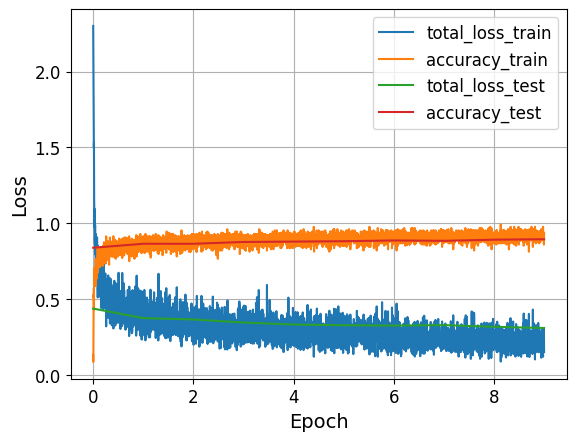

End of the training


In [94]:
train_model(
    model,
    loss_fn=loss_func,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=num_epochs,
    optimizer=opt,
    scheduler=None,
    device=device,
)

In [95]:
def calculate_test_accuracy(model, test_loader, loss_fn, device):
    test_stats = eval_model(0, model, loss_fn, test_loader, device)
    accuracy = test_stats['accuracy']
    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy

# Example usage:
test_accuracy = calculate_test_accuracy(model, test_loader, loss_func, device)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db3f0712660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^Exception ignored in: 
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7db3f0712660>assert self._parent_pid == os.getpid(), 'can only test a child process'

Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
      self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
       if w.is_alive(): 
  ^ ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^^^^^^

Evaluating epoch 0:   0%|          | 0/40 [00:00<?, ?it/s]

<function _MultiProcessingDataLoaderIter.__del__ at 0x7db3f0712660>^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    
Traceback (most recent call last):
assert self._parent_pid == os.getpid(), 'can only test a child process'
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
      self._shutdown_workers()  
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
      if w.is_alive(): 
 ^^ ^^^ ^ ^^ ^^ ^ ^^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

    AssertionErrorassert self._parent_pid == os.getpid(), 'can only test a child process': 
can only test a child process
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Test Accuracy: 0.8947


### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accuracy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [96]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [97]:
torchsummary.summary(OverfittingNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 1024]         803,840
              ReLU-3                 [-1, 1024]               0
            Linear-4                  [-1, 512]         524,800
              ReLU-5                  [-1, 512]               0
            Linear-6                  [-1, 256]         131,328
              ReLU-7                  [-1, 256]               0
            Linear-8                   [-1, 10]           2,570
Total params: 1,462,538
Trainable params: 1,462,538
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 5.58
Estimated Total Size (MB): 5.62
----------------------------------------------------------------


In [119]:
model2 = OverfittingNeuralNetwork().to(device)
opt = torch.optim.Adam(model2.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()

# Your experiments, come here

In [120]:
len(fmnist_dataset_train.data)

60000

In [121]:
train_subset = torch.utils.data.Subset(
    fmnist_dataset_train,
    indices=list(range(10000))
)

In [122]:
train_loader_reduced = torch.utils.data.DataLoader(train_subset,
                                                  batch_size=128,
                                                  shuffle=True,
                                                  num_workers=2)

Epoch: 10, Train Loss: 0.2611, Train Accuracy: 0.9012, Test Loss: 0.4418, Test Accuracy: 0.8556


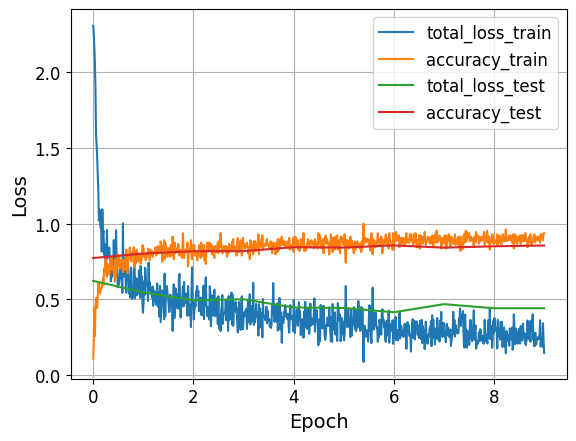

End of the training


In [123]:
train_model(
    model2,
    loss_fn=loss_func,
    train_loader=train_loader_reduced,
    test_loader=test_loader,
    epochs=num_epochs,
    optimizer=opt,
    scheduler=None,
    device=device,
)

### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

In [124]:
class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here

            nn.Linear(input_shape, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [125]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 2048]       1,607,680
       BatchNorm1d-3                 [-1, 2048]           4,096
              ReLU-4                 [-1, 2048]               0
           Dropout-5                 [-1, 2048]               0
            Linear-6                 [-1, 1024]       2,098,176
       BatchNorm1d-7                 [-1, 1024]           2,048
              ReLU-8                 [-1, 1024]               0
           Dropout-9                 [-1, 1024]               0
           Linear-10                  [-1, 512]         524,800
      BatchNorm1d-11                  [-1, 512]           1,024
             ReLU-12                  [-1, 512]               0
          Dropout-13                  [-1, 512]               0
           Linear-14                   

In [128]:
model3 = FixedNeuralNetwork().to(device)
opt = torch.optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)
loss_func = nn.CrossEntropyLoss()

# Your experiments, come here

In [129]:
train_subset2 = torch.utils.data.Subset(
    fmnist_dataset_train,
    indices=list(range(20000))
)

In [130]:
train_loader_reduced2 = torch.utils.data.DataLoader(train_subset2,
                                                  batch_size=128,
                                                  shuffle=True,
                                                  num_workers=2)

Epoch: 10, Train Loss: 0.2778, Train Accuracy: 0.8956, Test Loss: 0.4078, Test Accuracy: 0.8599


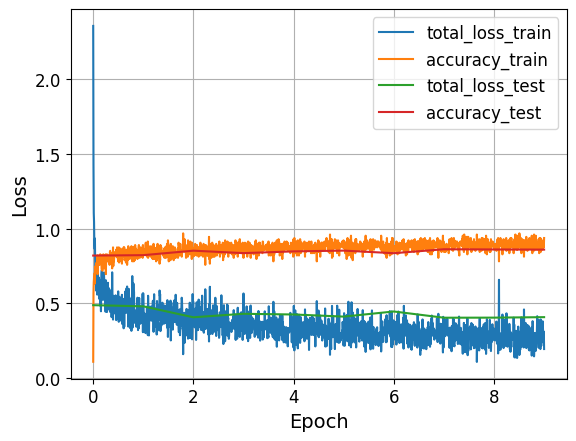

End of the training


In [131]:
train_model(
    model3,
    loss_fn=loss_func,
    train_loader=train_loader_reduced2,
    test_loader=test_loader,
    epochs=num_epochs,
    optimizer=opt,
    scheduler=None,
    device=device,
)

### Conclusions:
_Write down small report with your conclusions and your ideas._

Выводы:
1) Для того, чтобы добиться переобучения (лосс на трейне падает, на тесте растет), усложнили модель, сократили датасет
2) Чтобы исправить переобучение, добавили batchnorm и dropout. Добавили регуляризацию в оптимизатор. Увеличили датасет, потому что на маленьком слишком жестко переобучается. Можно было вместо увеличения датасета добавить аугментации.
3) Стоит добавить сохранение модели по лучшей валидации и ограничение на количество эпох, за которые может продолжаться стагнация, чтобы останавливать обучение, когда начинается переобучение